# This notebook is for the skill predictor for Starcraft Skill

In [24]:
# Imports
import numpy as np 
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import norm

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [17]:
# Load training data

# Read the raw CSV file into a list of lines.
with open('starcraft/train.csv') as f:
    train_lines = f.read().split('\n')
with open('starcraft/test.csv') as f:
    test_lines = f.read().split('\n')
 
# Assign a compact numeric index to each unique player name.
p = 0
playerid = {}
for line in train_lines + test_lines:
    row = line.split(',')
    if len(row) != 10:
        continue
    for name in (row[1], row[4]):
        if name not in playerid:
            playerid[name] = p
            p += 1
 
# Number of unique players and a reverse lookup for names.
nplayers = len(playerid)
playername = [''] * nplayers
for name, pid in playerid.items():
    playername[pid] = name
 
# Build win/play counts and store full game records for later use.
pKeep = 1.0   # fraction of game records to include (1.0 = keep all)
nEdge = 3     # target number of opponents per player
nKeep = 5     # maximum number of games to keep per player pair
 
nplays = np.zeros((nplayers, nplayers))
nwins = np.zeros((nplayers, nplayers))
 
# Each entry: (id_a, id_b, a_won:float, class_a:str, class_b:str, venue:str)
game_records = []
all_classes = set()
all_venues = set()
 
for line in train_lines:
    row = line.split(',')
    if len(row) != 10:
        continue
 
    # Extract both players and result fields.
    a_name, b_name = row[1], row[4]
    a_won = (row[2] == '[winner]')
    b_won = (row[5] == '[winner]')
    is_draw = a_won and b_won
    class_a = row[6].strip()
    class_b = row[7].strip()
    venue = row[9].strip()
 
    # Track all seen unit races and venues
    all_classes.update([class_a, class_b])
    all_venues.add(venue)
 
    a, b = playerid[a_name], playerid[b_name]
 
    # Filter game records by random sampling, nkeep, and nedge criteria.
    # In case of ties, credit each player with a half-win and half-loss.
    if np.random.rand() < pKeep:
        if (nplays[a, b] < nKeep) and \
           (((nplays[a, :] > 0).sum() < nEdge) or ((nplays[:, b] > 0).sum() < nEdge)):
            nplays[a, b] += 1
            nplays[b, a] += 1
            nwins[a, b] += 0.5 if is_draw else float(a_won)
            nwins[b, a] += 0.5 if is_draw else float(b_won)
            game_records.append((a, b, 0.5 if is_draw else float(a_won), class_a, class_b, venue))
 
# Build lookup tables for discrete context features.
classes = sorted(all_classes)
venues = sorted(all_venues)
class_idx = {c: i for i, c in enumerate(classes)}
venue_idx = {v: i for i, v in enumerate(venues)}
NC, NV = len(classes), len(venues)
 
print("Training data:")
print(f"Players : {nplayers}")
print(f"Classes : {classes}")
print(f"Venues  : {venues}")
print(f"Games   : {len(game_records)}")

# Process test data in the same way, but only keep player indices and outcomes.
test_records = []
for line in test_lines:
    row = line.split(',')
    if len(row) != 10:
        continue
    a_name, b_name = row[1], row[4]
    a_won = row[2] == '[winner]'
    b_won = row[5] == '[winner]'
    is_draw = a_won and b_won
    class_a = row[6].strip()
    class_b = row[7].strip()
    a, b = playerid[a_name], playerid[b_name]
    test_records.append((a, b, 0.5 if is_draw else float(a_won), class_a, class_b))


print("\nTesting data:")
print(f"Players seen in test : {len(set(a for a,b,*_ in test_records) | set(b for a,b,*_ in test_records))}")
print(f"Games                : {len(test_records)}")

Training data:
Players : 999
Classes : ['P', 'R', 'T', 'Z']
Venues  : ['offline', 'online']
Games   : 4677

Testing data:
Players seen in test : 999
Games                : 94007


# Installments
hots = heart of the swarm (Z)

lotv = legacy of the void (P) ( newest and which most people play on )

wol = wings of liberty (T) ( oldest )
# Classes
Protoss (P)

Terran (T)

Zerg (Z)

(07/17/2016,MC,[loser],0–1,Cure,[winner],P,T,LotV,offline)

(Example entry)

In [4]:
# Latent Variable Skill Model
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

In [11]:
class LatentSkillModelWithRaces:
    """
    Maintains a Gaussian posterior N(mu_i, sigma_i^2) per player.
    P(i beats j) = sigmoid(mu_i - mu_j)
    Updates are a Laplace approximation:
      - mu updated via gradient of log-likelihood
      - sigma updated via observed Fisher information
    """

    def __init__(self, nplayers, nraces, prior_mu=0.0, prior_sigma=1.0, lr=0.01):
        self.nplayers = nplayers
        self.prior_mu = prior_mu
        self.nraces = nraces
        self.prior_sigma = prior_sigma
        self.lr = lr
        
        self.mu = np.full(nplayers, prior_mu, dtype=float)
        self.sigma = np.full(nplayers, prior_sigma, dtype=float)
        self.n_games = np.zeros(nplayers, dtype=int)
        
        self.race_mu = np.zeros(nraces, dtype=float)
        self.race_sigma = np.full(nraces, prior_sigma, dtype=float)

    def update(self, a, b, c_a, c_b, a_won):
        """Single-game posterior update for players a and b."""
        z = (self.mu[a] - self.mu[b]) + (self.race_mu[c_a] - self.race_mu[c_b])
        p_a = sigmoid(z)
        err = a_won - p_a
        fisher = p_a * (1.0 - p_a)

        # Update mu using gradient of log-likelihood.
        self.mu[a] += self.lr * self.sigma[a]**2 * err
        self.mu[b] -= self.lr * self.sigma[b]**2 * err
        self.race_mu[c_a] += self.lr * self.race_sigma[c_a]**2 * err
        self.race_mu[c_b] -= self.lr * self.race_sigma[c_b]**2 * err

        # Update sigma using observed Fisher information.
        self.sigma[a] = 1.0 / np.sqrt(1.0 / self.sigma[a]**2 + fisher)
        self.sigma[b] = 1.0 / np.sqrt(1.0 / self.sigma[b]**2 + fisher)
        self.race_sigma[c_a] = 1.0 / np.sqrt(1.0 / self.race_sigma[c_a]**2 + fisher)
        self.race_sigma[c_b] = 1.0 / np.sqrt(1.0 / self.race_sigma[c_b]**2 + fisher)

        # Update game count.
        self.n_games[a] += 1
        self.n_games[b] += 1

    def fit(self, game_records, class_idx, n_passes=5, print_every=5, tol=1e-4):
        """Run n_passes passes of updates over the game records or until delta reaches tol."""
        self.mu[:] = self.prior_mu
        self.sigma[:] = self.prior_sigma
        self.n_games[:] = 0
        for pass_num in range(n_passes):
            mu_before = self.mu.copy()
            #Categorical features implementeation
            for a, b, a_won, class_a, class_b, venue in game_records:
                c_a = class_idx[class_a]
                c_b = class_idx[class_b]
                self.update(a, b, c_a, c_b, a_won)
                
            delta = np.abs(self.mu - mu_before).mean()
            if (pass_num + 1) % print_every == 0:
                print(f"Pass {pass_num+1}: mean |Δμ| = {delta:.6f}")
            if delta < tol:
                print(f"Converged at pass {pass_num+1}.")
                break

    def predict(self, a, b, c_a, c_b):
        """P(a beats b) including race advantage."""
        z = (self.mu[a] - self.mu[b]) + (self.race_mu[c_a] - self.race_mu[c_b])
        return sigmoid(z)

    def top_k(self, k=20):
        """Print the top k players by posterior mean skill."""
        ranked = np.argsort(self.mu)[::-1]
        print(f"\n{'Rank':<5} {'Player':<22} {'μ':>8} {'σ':>8} {'Games':>6}")
        print("-" * 55)
        for rank, pid in enumerate(ranked[:k], 1):
            print(f"{rank:<5} {playername[pid]:<22} {self.mu[pid]:>8.4f} "
                  f"{self.sigma[pid]:>8.4f} {self.n_games[pid]:>6}")

In [6]:
class LatentSkillModel:
    """
    Maintains a Gaussian posterior N(mu_i, sigma_i^2) per player.
    P(i beats j) = sigmoid(mu_i - mu_j)
    Updates are a Laplace approximation:
      - mu updated via gradient of log-likelihood
      - sigma updated via observed Fisher information
    """

    def __init__(self, nplayers, prior_mu=0.0, prior_sigma=1.0, lr=0.01):
        self.nplayers = nplayers
        self.prior_mu = prior_mu
        self.prior_sigma = prior_sigma
        self.lr = lr
        
        self.mu = np.full(nplayers, prior_mu, dtype=float)
        self.sigma = np.full(nplayers, prior_sigma, dtype=float)
        self.n_games = np.zeros(nplayers, dtype=int)
        
    def update(self, a, b, a_won):
        """Single-game posterior update for players a and b."""
        p_a = sigmoid(self.mu[a] - self.mu[b])
        err = a_won - p_a
        fisher = p_a * (1.0 - p_a)

        # Update mu using gradient of log-likelihood.
        self.mu[a] += self.lr * self.sigma[a]**2 * err
        self.mu[b] -= self.lr * self.sigma[b]**2 * err

        # Update sigma using observed Fisher information.
        self.sigma[a] = 1.0 / np.sqrt(1.0 / self.sigma[a]**2 + fisher)
        self.sigma[b] = 1.0 / np.sqrt(1.0 / self.sigma[b]**2 + fisher)

        # Update game count.
        self.n_games[a] += 1
        self.n_games[b] += 1

    def fit(self, game_records, n_passes=5, print_every=5, tol=1e-4):
        """Run n_passes passes of updates over the game records or until delta reaches tol."""
        self.mu[:] = self.prior_mu
        self.sigma[:] = self.prior_sigma
        self.n_games[:] = 0
        for pass_num in range(n_passes):
            mu_before = self.mu.copy()
            #Ignore categorical features for now, can implement later
            for a, b, a_won, *_ in game_records:
                self.update(a, b, a_won)
            delta = np.abs(self.mu - mu_before).mean()
            if (pass_num + 1) % print_every == 0:
                print(f"Pass {pass_num+1}: mean |Δμ| = {delta:.6f}")
            if delta < tol:
                print(f"Converged at pass {pass_num+1}.")
                break

    def predict(self, a, b):
        """P(a beats b) under current posterior means."""
        return sigmoid(self.mu[a] - self.mu[b])

    def top_k(self, k=20):
        """Print the top k players by posterior mean skill."""
        ranked = np.argsort(self.mu)[::-1]
        print(f"\n{'Rank':<5} {'Player':<22} {'μ':>8} {'σ':>8} {'Games':>6}")
        print("-" * 55)
        for rank, pid in enumerate(ranked[:k], 1):
            print(f"{rank:<5} {playername[pid]:<22} {self.mu[pid]:>8.4f} "
                  f"{self.sigma[pid]:>8.4f} {self.n_games[pid]:>6}")

In [7]:
model = LatentSkillModel(nplayers, lr=0.01)
model.fit(game_records, n_passes=200, print_every=10, tol=1e-4)
model.top_k(k=20)

Pass 10: mean |Δμ| = 0.001323
Pass 20: mean |Δμ| = 0.000666
Pass 30: mean |Δμ| = 0.000444
Pass 40: mean |Δμ| = 0.000332
Pass 50: mean |Δμ| = 0.000265
Pass 60: mean |Δμ| = 0.000221
Pass 70: mean |Δμ| = 0.000189
Pass 80: mean |Δμ| = 0.000165
Pass 90: mean |Δμ| = 0.000147
Pass 100: mean |Δμ| = 0.000132
Pass 110: mean |Δμ| = 0.000120
Pass 120: mean |Δμ| = 0.000110
Pass 130: mean |Δμ| = 0.000101
Converged at pass 132.

Rank  Player                        μ        σ  Games
-------------------------------------------------------
1     Snute                    0.1305   0.0091  48972
2     ByuN                     0.1289   0.0132  22968
3     Hydra                    0.1163   0.0291   4752
4     TRUE                     0.1124   0.0247   6600
5     INnoVation               0.1119   0.0160  15708
6     Nerchio                  0.1099   0.0086  54120
7     Neeb                     0.1083   0.0215   8712
8     Stephano                 0.1049   0.0178  12672
9     Scarlett                 0.1043   

In [12]:
race_model = LatentSkillModelWithRaces(nplayers, nraces=NC, lr=0.01)
race_model.fit(game_records, class_idx=class_idx, n_passes=200, print_every=10, tol=1e-4)

Pass 10: mean |Δμ| = 0.001322
Pass 20: mean |Δμ| = 0.000665
Pass 30: mean |Δμ| = 0.000443
Pass 40: mean |Δμ| = 0.000332
Pass 50: mean |Δμ| = 0.000265
Pass 60: mean |Δμ| = 0.000221
Pass 70: mean |Δμ| = 0.000189
Pass 80: mean |Δμ| = 0.000165
Pass 90: mean |Δμ| = 0.000147
Pass 100: mean |Δμ| = 0.000132
Pass 110: mean |Δμ| = 0.000120
Pass 120: mean |Δμ| = 0.000110
Pass 130: mean |Δμ| = 0.000101
Converged at pass 132.


## Evaluation ##

Here we evaluate the model's performance on the testing data based off at raw accuracy and also log-likelihood. We only test on games where both players are in the training set. This filtering was done when we loaded the testing data alongside the training data.

In [13]:
correct = 0
total = 0
log_loss = 0.0
eps = 1e-7

for a, b, a_won in test_records:
    p_a = model.predict(a, b)
    p_a_clipped = np.clip(p_a, eps, 1 - eps)
    
    correct += int((p_a > 0.5) == (a_won > 0.5))
    log_loss -= a_won * np.log(p_a_clipped) + (1 - a_won) * np.log(1 - p_a_clipped)
    total += 1

print(f"Test accuracy : {correct}/{total} = {correct/total:.4f}")
print(f"Test log-loss : {log_loss/total:.4f}  (random baseline = {np.log(2):.4f})")

Test accuracy : 56647/94007 = 0.6026
Test log-loss : 0.6826  (random baseline = 0.6931)


In [18]:
correct = 0
total = 0
log_loss = 0.0
eps = 1e-7

for a, b, a_won, class_a, class_b in test_records:
    c_a = class_idx.get(class_a, 0) 
    c_b = class_idx.get(class_b, 0)
    p_a = race_model.predict(a, b, c_a, c_b)
    p_a_clipped = np.clip(p_a, eps, 1 - eps)
    
    correct += int((p_a > 0.5) == (a_won > 0.5))
    log_loss -= a_won * np.log(p_a_clipped) + (1 - a_won) * np.log(1 - p_a_clipped)
    total += 1

print(f"Test accuracy : {correct}/{total} = {correct/total:.4f}")
print(f"Test log-loss : {log_loss/total:.4f}  (random baseline = {np.log(2):.4f})")

Test accuracy : 56489/94007 = 0.6009
Test log-loss : 0.6826  (random baseline = 0.6931)


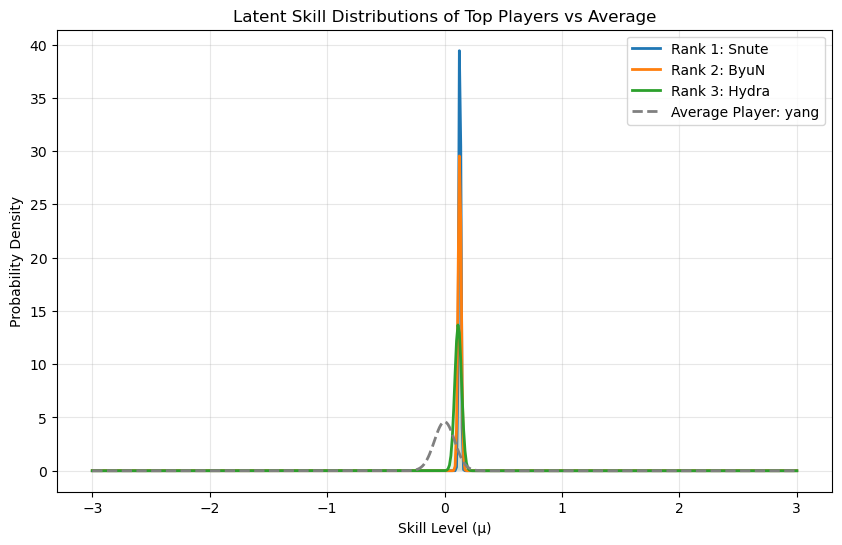

In [ ]:
# Visualize the results

def plot_skill_distributions(model, playername, top_k=3):
    plt.figure(figsize=(10, 6))
    
    x = np.linspace(-3, 3, 500)
    
    # Find the top players 
    ranked_indices = np.argsort(model.mu)[::-1]
    top_players = ranked_indices[:top_k]
    
    # Find an average player (mu closest to 0)
    avg_player = np.argmin(np.abs(model.mu - 0.0))
    
    # Plot top players
    for pid in top_players:
        mu, sigma = model.mu[pid], model.sigma[pid]
        y = norm.pdf(x, mu, sigma)
        plt.plot(x, y, label=f"Rank {np.where(ranked_indices == pid)[0][0] + 1}: {playername[pid]}", linewidth=2)
        plt.fill_between(x, y, alpha=0.1)

    # Plot the baseline/average player
    mu, sigma = model.mu[avg_player], model.sigma[avg_player]
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, label=f"Average Player: {playername[avg_player]}", linestyle='--', color='gray', linewidth=2)
    
    plt.title("Latent Skill Distributions of Top Players vs Average")
    plt.xlabel("Skill Level (μ)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_skill_distributions(model, playername)

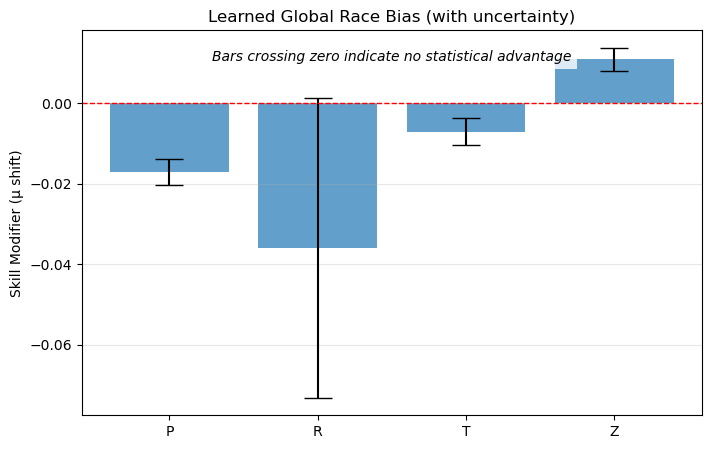

In [ ]:
def plot_race_bias(model, classes):
    plt.figure(figsize=(8, 5))
    
    # Extract means and standard deviations
    means = model.race_mu
    errors = model.race_sigma
    
    # Create bar chart with error bars
    x_pos = np.arange(len(classes))
    plt.bar(x_pos, means, yerr=errors, align='center', alpha=0.7, ecolor='black', capsize=10)
    
    # Add a horizontal line at 0 for reference
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    
    plt.xticks(x_pos, classes)
    plt.title("Learned Global Race Bias (with uncertainty)")
    plt.ylabel("Skill Modifier (μ shift)")
    plt.grid(axis='y', alpha=0.3)
             
    plt.show()

plot_race_bias(race_model, classes)

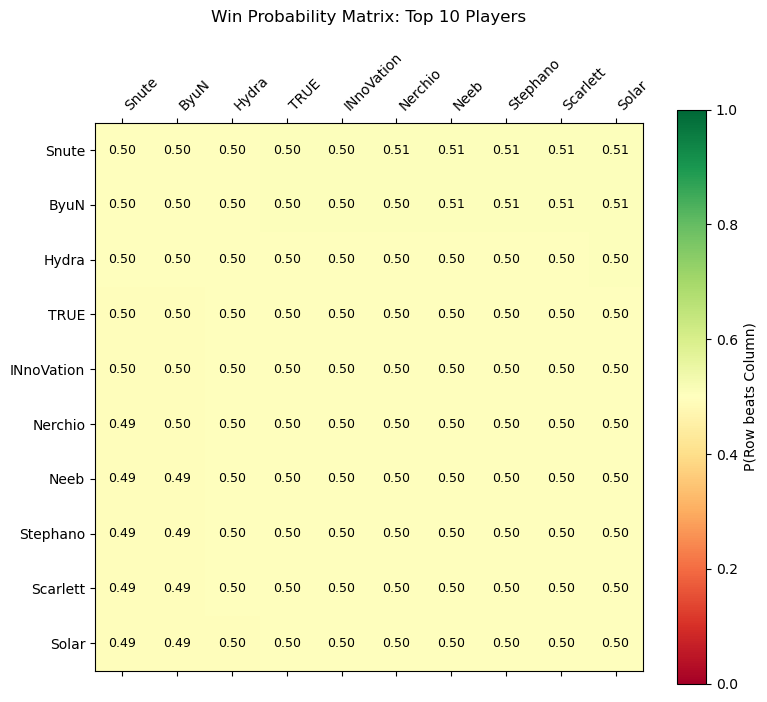

In [29]:
def plot_win_probability_matrix(model, playername, top_k=10):
    # Get the top K players
    ranked_indices = np.argsort(model.mu)[::-1]
    top_players = ranked_indices[:top_k]
    names = [playername[pid] for pid in top_players]
    
    # Initialize a K x K matrix
    matrix = np.zeros((top_k, top_k))
    
    # Calculate P(Row beats Column)
    for i in range(top_k):
        for j in range(top_k):
            p_i = top_players[i]
            p_j = top_players[j]
            # Using the basic player-vs-player logic (ignoring race for the general heatmap)
            matrix[i, j] = sigmoid(model.mu[p_i] - model.mu[p_j])
            
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)  # Red to Green colormap
    
    # Add colorbar
    fig.colorbar(cax, shrink=0.8, label="P(Row beats Column)")
    
    # Set ticks and labels
    ax.set_xticks(np.arange(top_k))
    ax.set_yticks(np.arange(top_k))
    ax.set_xticklabels(names, rotation=45, ha='left')
    ax.set_yticklabels(names)
    
    # Add text annotations inside each square
    for i in range(top_k):
        for j in range(top_k):
            val = matrix[i, j]
            # Use white text for dark colors (high/low probabilities) and black for middle
            text_color = "white" if val < 0.2 or val > 0.8 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=9)

    plt.title(f"Win Probability Matrix: Top {top_k} Players", pad=20)
    plt.tight_layout()
    plt.show()

plot_win_probability_matrix(model, playername, top_k=10)

# Sources:

Dataset: Provided from Canvas

NumPy: Harris, C.R., Millman, K.J., van der Walt, S.J. et al. Array programming with NumPy. Nature 585, 357–362 (2020). DOI: 10.1038/s41586-020-2649-2. (Publisher link).
MatPlotLib:  J. D. Hunter, "Matplotlib: A 2D Graphics Environment", Computing in Science & Engineering, vol. 9, no. 3, pp. 90-95, 2007.
SciPy:Pauli Virtanen, Ralf Gommers, Travis E. Oliphant, Matt Haberland, Tyler Reddy, David Cournapeau, Evgeni Burovski, Pearu Peterson, Warren Weckesser, Jonathan Bright, Stéfan J. van der Walt, Matthew Brett, Joshua Wilson, K. Jarrod Millman, Nikolay Mayorov, Andrew R. J. Nelson, Eric Jones, Robert Kern, Eric Larson, CJ Carey, İlhan Polat, Yu Feng, Eric W. Moore, Jake VanderPlas, Denis Laxalde, Josef Perktold, Robert Cimrman, Ian Henriksen, E.A. Quintero, Charles R Harris, Anne M. Archibald, Antônio H. Ribeiro, Fabian Pedregosa, Paul van Mulbregt, and SciPy 1.0 Contributors. (2020) SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. Nature Methods, 17(3), 261-272. DOI: 10.1038/s41592-019-0686-2.